In [26]:
%load_ext cudf.pandas
import pandas as pd
import numpy as np

import os                          # to access data within folders in kaggle 
import glob                        # used to search for files matching a pattern and return their full file paths.
from PIL import Image              # used to import images

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

import warnings
warnings.filterwarnings('ignore')

The cudf.pandas extension is already loaded. To reload it, use:
  %reload_ext cudf.pandas


In [27]:
path = "/kaggle/input/datasets/ashura369/sign-language-dataset/test/1"

# getting all the imgs in folder '1'
img_files = glob.glob(os.path.join(path, '*'))

print(f"TOTAL IMGS FOUND IN FOLDER : {len(img_files)}")



TOTAL IMGS FOUND IN FOLDER : 31


#### Plotting All The Images in Folder `1`

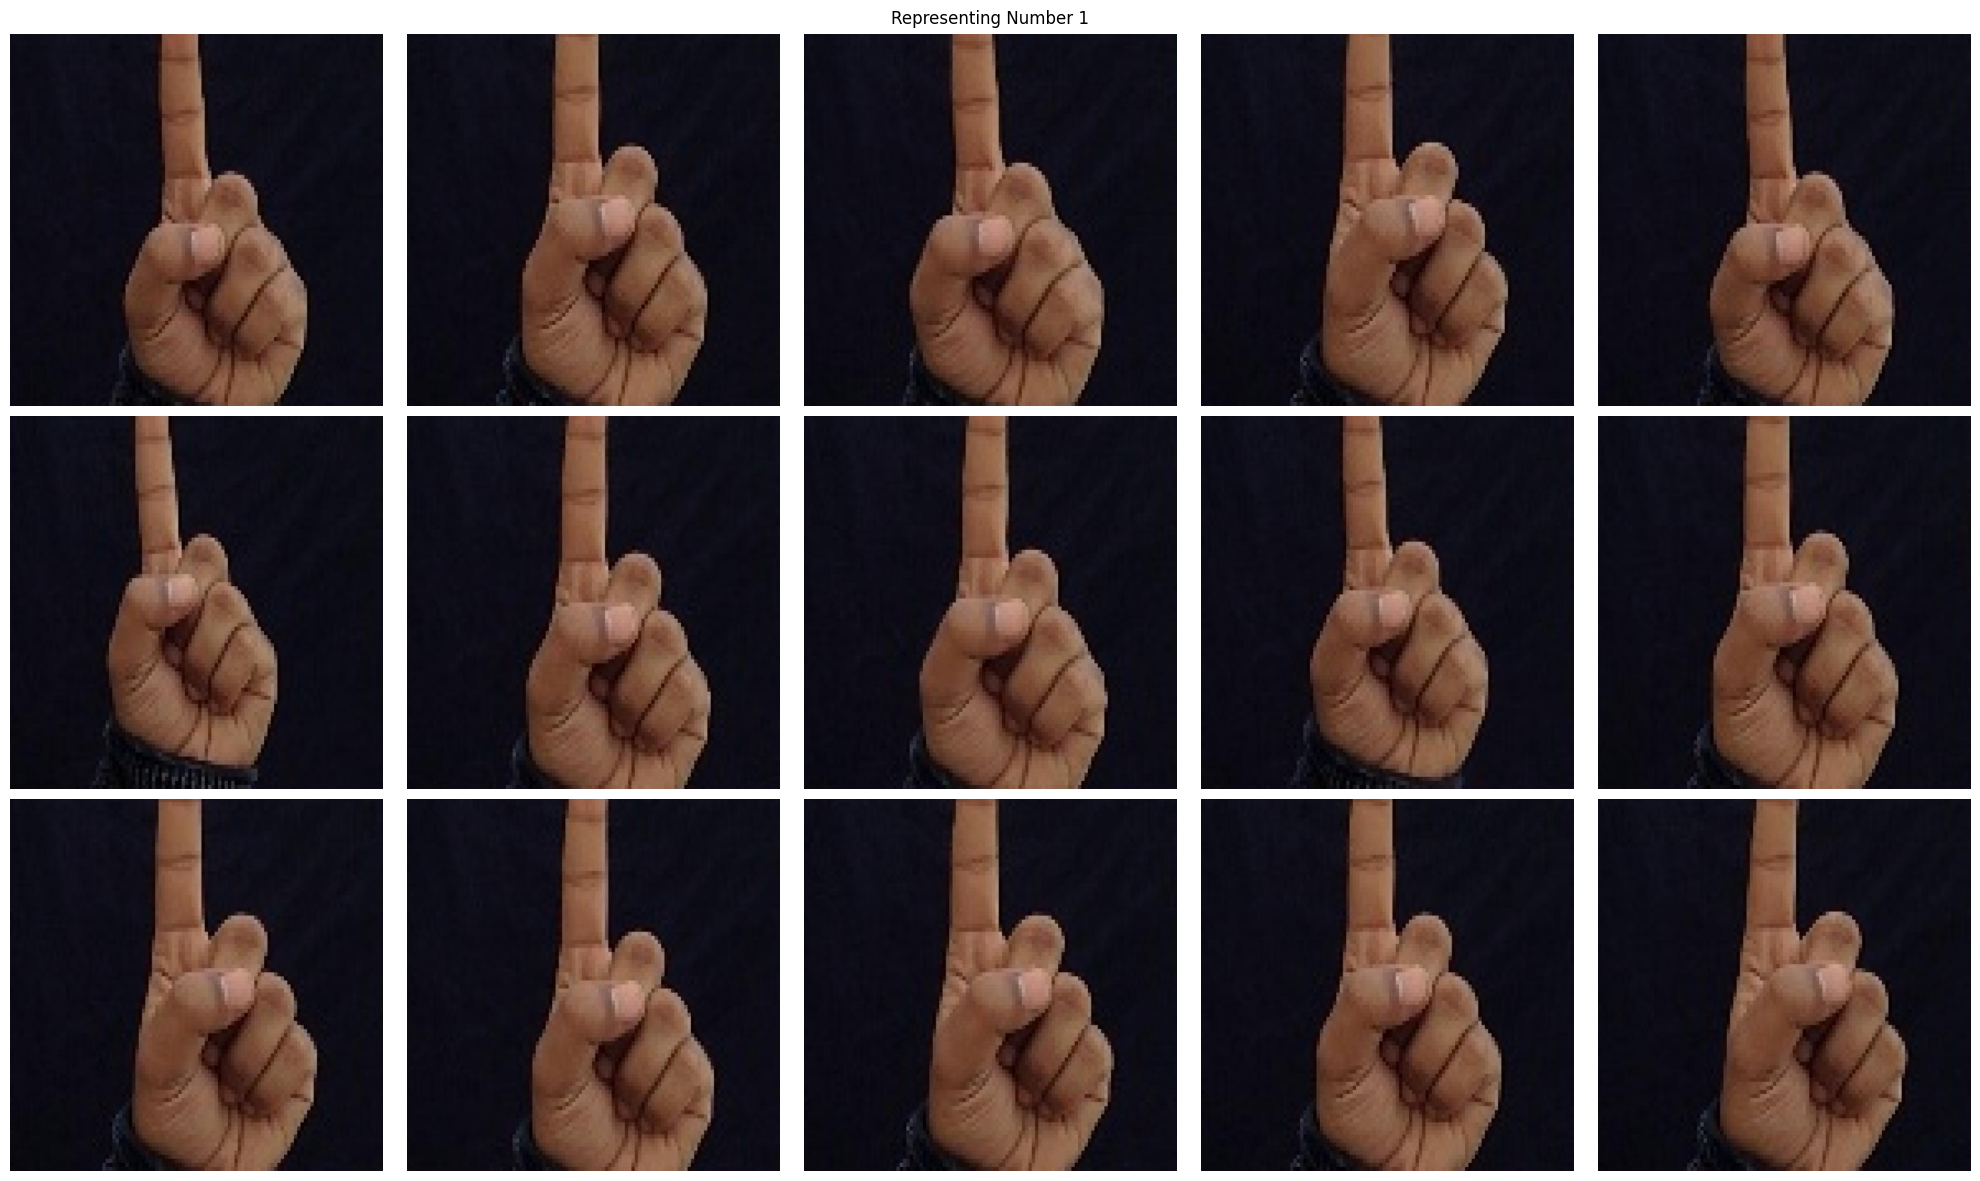

In [28]:
rows = 3
cols = 5
temp = rows * cols

plt.figure(figsize=(20,12))

for i in range(min(temp, len(img_files))):
    plt.subplot(rows, cols, i+1)
    plt.imshow(Image.open(img_files[i]))
    plt.axis('off')
plt.suptitle('Representing Number 1')
plt.tight_layout()
plt.show()

In [29]:
path = "/kaggle/input/datasets/ashura369/sign-language-dataset/train/2"

img_file = glob.glob(os.path.join(path, '*'))

len(img_file)

352

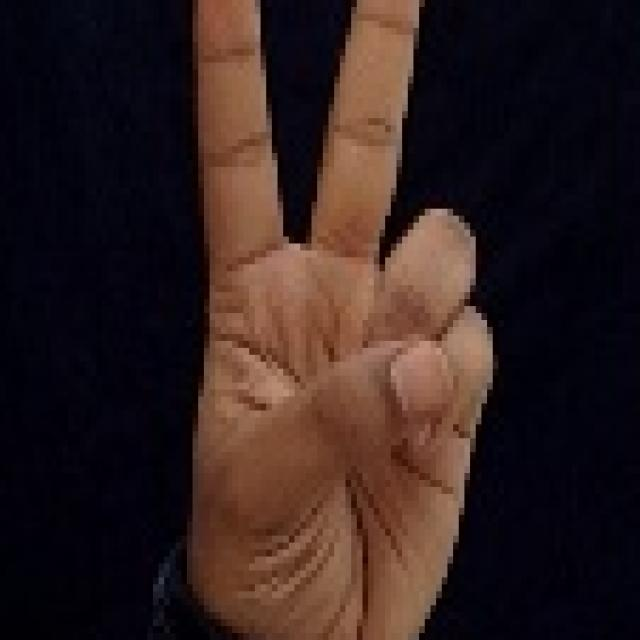

In [30]:
Image.open(img_file[5])

In [31]:
path = "/kaggle/input/datasets/ashura369/sign-language-dataset"
files = glob.glob(os.path.join(path, "*"))
print(len(files))
print(files)

5
['/kaggle/input/datasets/ashura369/sign-language-dataset/README.dataset.txt', '/kaggle/input/datasets/ashura369/sign-language-dataset/README.roboflow.txt', '/kaggle/input/datasets/ashura369/sign-language-dataset/valid', '/kaggle/input/datasets/ashura369/sign-language-dataset/test', '/kaggle/input/datasets/ashura369/sign-language-dataset/train']


#### Extracting All The Folder Names

In [32]:
path = "/kaggle/input/datasets/ashura369/sign-language-dataset/train"
folder_names = sorted(os.listdir(path))

In [33]:
folder_names

['1',
 '2',
 '3',
 '4',
 '5',
 '6',
 '7',
 '8',
 '9',
 'A',
 'B',
 'C',
 'D',
 'E',
 'F',
 'G',
 'H',
 'I',
 'J',
 'K',
 'L',
 'M',
 'N',
 'O',
 'P',
 'Q',
 'R',
 'S',
 'T',
 'U',
 'V',
 'W',
 'X',
 'Y',
 'Z']

#### Using Pre-Trained Model

In [34]:
import tensorflow as tf
from tensorflow.keras import layers, models, Sequential
from tensorflow.keras.applications import MobileNetV2

In [35]:
img_size = (180,180)
base_model = MobileNetV2(
    input_shape=(180,180,3),
    include_top = False,
    weights = 'imagenet'
)

base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.2),
    layers.Dense(len(folder_names), activation='softmax')
])

In [36]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 6, 6, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 35)             │        44,835 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,302,819 (8.78 MB)

 Trainable params: 44,835 (175.14 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

#### Model Training

In [37]:
train_path = "/kaggle/input/datasets/ashura369/sign-language-dataset/train"
val_path = "/kaggle/input/datasets/ashura369/sign-language-dataset/valid"

train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_path,
    image_size = img_size,
    batch_size=64,
    label_mode = 'int'
)

val_dataset = tf.keras.utils.image_dataset_from_directory(
    val_path,
    image_size=(180, 180),
    batch_size=64
)

model.compile(
    optimizer='adam', 
    loss='sparse_categorical_crossentropy', # Change to your specific loss function (e.g., 'binary_crossentropy', 'mse', etc.)
    metrics=['accuracy']
)

Found 13860 files belonging to 35 classes.
Found 1980 files belonging to 35 classes.


In [38]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# 1. Callback to save ONLY the best model based on validation accuracy
checkpoint = ModelCheckpoint(
    'best_sign_language_model.keras',  # Output filename
    monitor='val_accuracy',             # Metric to track
    mode='max',                         # Save when metric is highest
    save_best_only=True,                # Overwrites only if performance improves
    verbose=1
)

# 2. Callback to stop training early if validation accuracy stops improving
early_stopping = EarlyStopping(
    monitor='val_accuracy',
    patience=3,                          # Stop if no improvement for 3 consecutive epochs
    restore_best_weights=True,           # Restore best weights at the end of training
    verbose=1
)

In [39]:
history = model.fit(
    train_dataset, epochs=10, validation_data = val_dataset,
    callbacks=[checkpoint, early_stopping]  
)

Epoch 1/10
217/217 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.5512 - loss: 1.9098
Epoch 1: val_accuracy improved from None to 0.99899, saving model to best_sign_language_model.keras

Epoch 1: finished saving model to best_sign_language_model.keras
217/217 ━━━━━━━━━━━━━━━━━━━━ 38s 134ms/step - accuracy: 0.7838 - loss: 1.0162 - val_accuracy: 0.9990 - val_loss: 0.0770
Epoch 2/10
216/217 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.9719 - loss: 0.2173
Epoch 2: val_accuracy improved from 0.99899 to 1.00000, saving model to best_sign_language_model.keras

Epoch 2: finished saving model to best_sign_language_model.keras
217/217 ━━━━━━━━━━━━━━━━━━━━ 16s 73ms/step - accuracy: 0.9765 - loss: 0.1859 - val_accuracy: 1.0000 - val_loss: 0.0249
Epoch 3/10
216/217 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.9886 - loss: 0.1088
Epoch 3: val_accuracy did not improve from 1.00000
217/217 ━━━━━━━━━━━━━━━━━━━━ 15s 70ms/step - accuracy: 0.9891 - loss: 0.0978 - val_accuracy: 1.0000 - val_loss: 0.

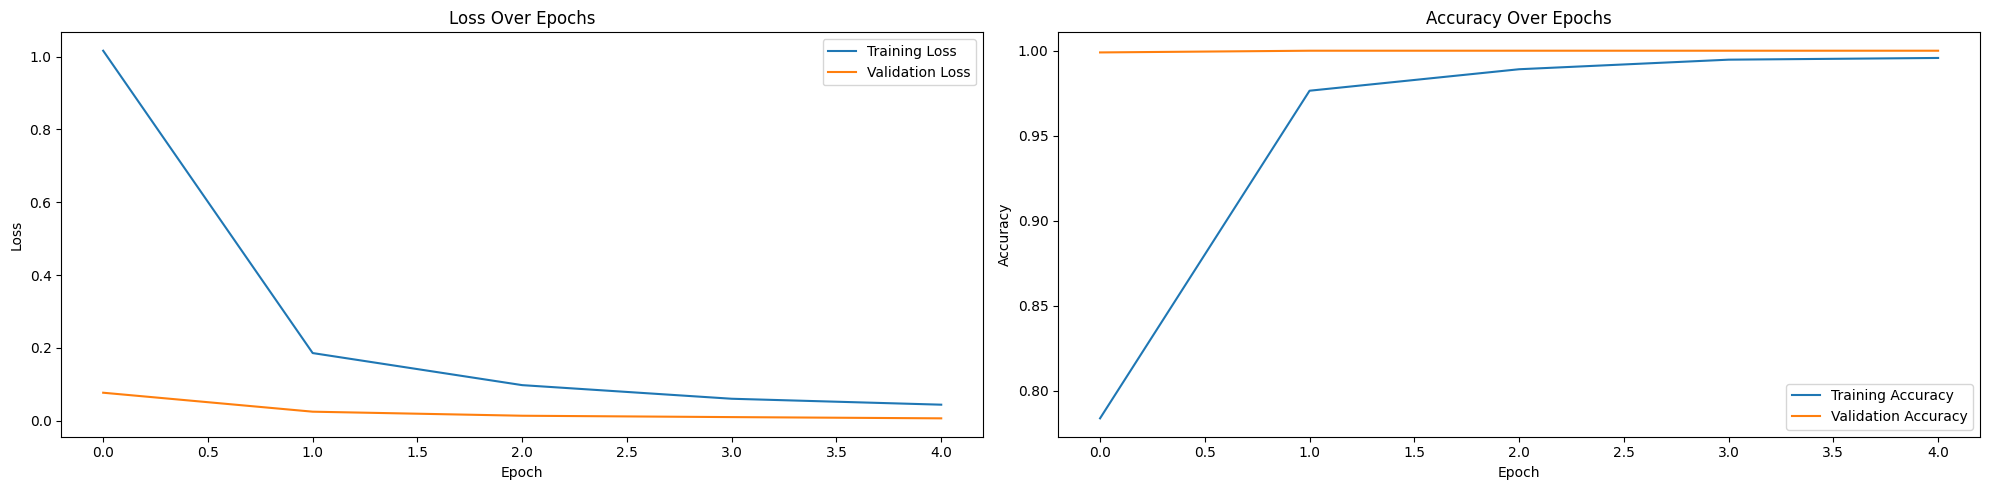

In [40]:
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 5))

# --- Subplot 1: Loss ---
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# --- Subplot 2: Accuracy ---
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

In [41]:
# 1. Find the best validation loss (minimum is best)
best_val_loss = min(history.history['val_loss'])
best_epoch_loss = history.history['val_loss'].index(best_val_loss) + 1
print(f"Best Validation Loss: {best_val_loss:.4f} (Achieved at Epoch {best_epoch_loss})")

best_val_acc = max(history.history['val_accuracy'])
best_epoch_acc = history.history['val_accuracy'].index(best_val_acc) + 1
print(f"Best Validation Accuracy: {best_val_acc:.4f} (Achieved at Epoch {best_epoch_acc})")

Best Validation Loss: 0.0066 (Achieved at Epoch 5)
Best Validation Accuracy: 1.0000 (Achieved at Epoch 2)


#### Checking The Precision of Model at Epoch 10

In [42]:
# Epoch 10 corresponds to index 9
epoch_index = 9 

print(f"---------- Metrics for Epoch 10 ----------")
print(f"Training Loss: {history.history['loss'][epoch_index]:.4f}")
print(f"Validation Loss: {history.history['val_loss'][epoch_index]:.4f}")

print(f"Training Accuracy: {history.history['accuracy'][epoch_index]:.4f}")
print(f"Validation Accuracy: {history.history['val_accuracy'][epoch_index]:.4f}")

---------- Metrics for Epoch 10 ----------


IndexError: list index out of range

#### Saving The Model at Epoch 10

In [ ]:
import tensorflow as tf
best_model = tf.keras.model.load_model("Sign_language_model.keras")